In [2]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Kütüphaneler yüklendi!")


Kütüphaneler yüklendi!


In [3]:
conn = psycopg2.connect(
    host="localhost",
    port="5432",
    database="tasarruf_finansman", 
    user="postgres",          
    password="2491"      
)

df = pd.read_sql("SELECT * FROM feature_view", conn)
conn.close()

print(df.shape)
df.head()

C:\Users\STJ086\AppData\Local\Temp\ipykernel_24336\2242404072.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM feature_view", conn)


(14105, 12)


,member_key,son_odeme_tarihi,toplam_odeme,toplam_tutar,frequency,recency_son_odeme,recency_uyelik,ort_gecikme_gun,son3ay_gecikme_trendi,odeme_std_sapma,bayram_gecikme_orani,kura_katilim_sayisi
0,1,20260509,19.0,2062500.04,0.158333,25,575,1.631579,-2.333333,57087.789535,0.0,1
1,2,20260524,22.0,3449402.91,0.183333,10,675,1.227273,-4.333333,36116.699810,0.0,0
2,3,20260507,5.0,250000.00,0.083333,27,160,0.000000,0.000000,27950.849719,0.0,1
3,4,20260427,38.0,3404744.83,0.791667,37,1200,0.184211,0.000000,75596.649869,0.0,0
4,5,20260502,23.0,525000.00,0.383333,32,720,0.391304,0.000000,7202.601638,0.0,2


In [4]:
print(df.isnull().sum())

member_key                 0
son_odeme_tarihi           0
toplam_odeme               0
toplam_tutar               0
frequency                  0
recency_son_odeme          0
recency_uyelik             0
ort_gecikme_gun            0
son3ay_gecikme_trendi    354
odeme_std_sapma          332
bayram_gecikme_orani       0
kura_katilim_sayisi        0
dtype: int64


In [5]:
df['son3ay_gecikme_trendi'] = df['son3ay_gecikme_trendi'].fillna(0)
df['odeme_std_sapma'] = df['odeme_std_sapma'].fillna(0)

# Kontrol
print(df.isnull().sum())

member_key               0
son_odeme_tarihi         0
toplam_odeme             0
toplam_tutar             0
frequency                0
recency_son_odeme        0
recency_uyelik           0
ort_gecikme_gun          0
son3ay_gecikme_trendi    0
odeme_std_sapma          0
bayram_gecikme_orani     0
kura_katilim_sayisi      0
dtype: int64


In [6]:
# K-Means için kullanacağımız feature'lar
features = [
    'recency_son_odeme',
    'recency_uyelik', 
    'frequency',
    'toplam_tutar',
    'ort_gecikme_gun',
    'son3ay_gecikme_trendi',
    'kura_katilim_sayisi',
    'odeme_std_sapma',
    'bayram_gecikme_orani'
]

# Normalize et
scaler = StandardScaler()
X = scaler.fit_transform(df[features])

print(X.shape)

(14105, 9)


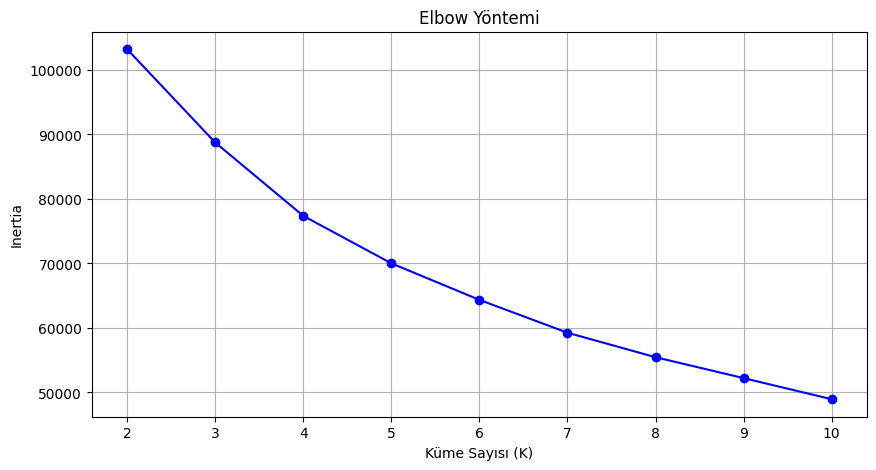

In [7]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Grafik
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Küme Sayısı (K)')
plt.ylabel('Inertia')
plt.title('Elbow Yöntemi')
plt.xticks(k_range)
plt.grid(True)
plt.show()

K=2: 0.2046
K=3: 0.2323
K=4: 0.2467
K=5: 0.2128
K=6: 0.2244
K=7: 0.2290
K=8: 0.2343
K=9: 0.2173
K=10: 0.2181


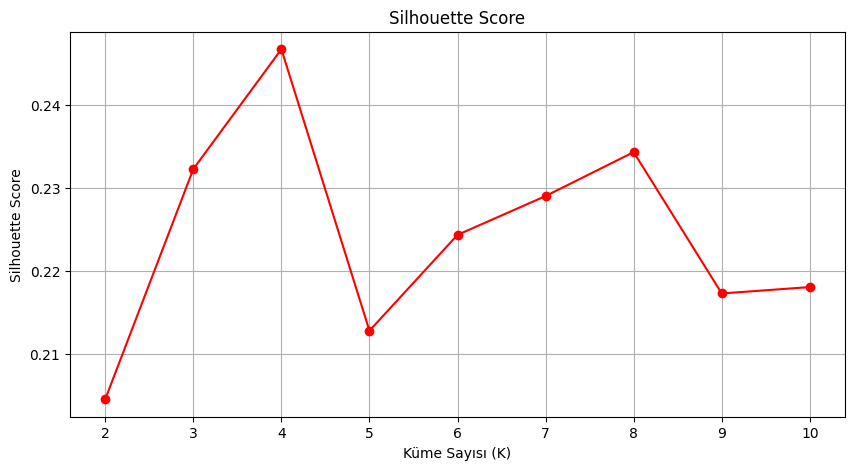

In [8]:
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f"K={k}: {score:.4f}")

# Grafik
plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores, 'ro-')
plt.xlabel('Küme Sayısı (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [9]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['segment'] = kmeans.fit_predict(X)

print(df['segment'].value_counts())

segment
0    6871
1    5629
2     991
3     614
Name: count, dtype: int64


In [10]:
profile = df.groupby('segment')[features].mean().round(2)
print(profile)

         recency_son_odeme  recency_uyelik  frequency  toplam_tutar  \
segment                                                               
0                    50.81          495.10       0.19     752986.69   
1                    38.28         1203.26       0.57    2852562.81   
2                  1019.37         1133.23       0.05     223421.59   
3                    48.56         1032.73       0.48    2202956.53   

         ort_gecikme_gun  son3ay_gecikme_trendi  kura_katilim_sayisi  \
segment                                                                
0                   0.60                   0.01                 0.90   
1                   0.62                  -0.05                 1.03   
2                   0.56                   0.00                 0.07   
3                   0.88                   0.11                 0.99   

         odeme_std_sapma  bayram_gecikme_orani  
segment                                         
0               21372.48                  

In [11]:
segment_map = {
    0: 'Yeni Potansiyeller',
    1: 'Sadık Üyeler',
    2: 'Terk Adayları',
    3: 'Riskli Üyeler'
}

df['segment_adi'] = df['segment'].map(segment_map)
print(df['segment_adi'].value_counts())

segment_adi
Yeni Potansiyeller    6871
Sadık Üyeler          5629
Terk Adayları          991
Riskli Üyeler          614
Name: count, dtype: int64


C:\Users\STJ086\AppData\Local\Temp\ipykernel_24336\2738535825.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='segment_adi',


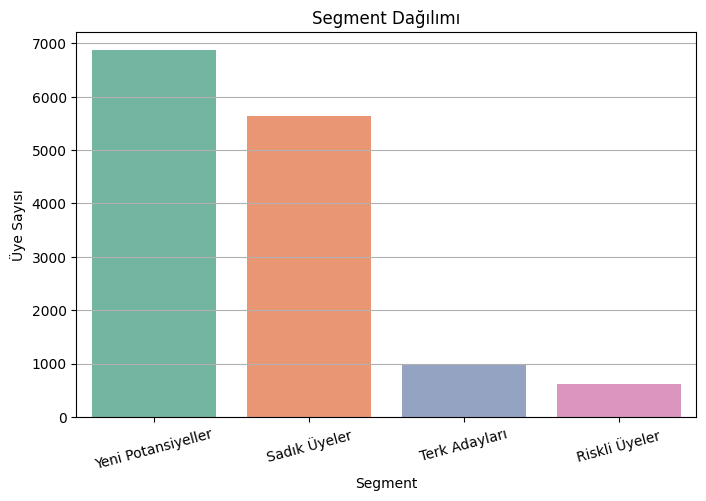

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='segment_adi', 
              order=df['segment_adi'].value_counts().index,
              palette='Set2')
plt.title('Segment Dağılımı')
plt.xlabel('Segment')
plt.ylabel('Üye Sayısı')
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.show()

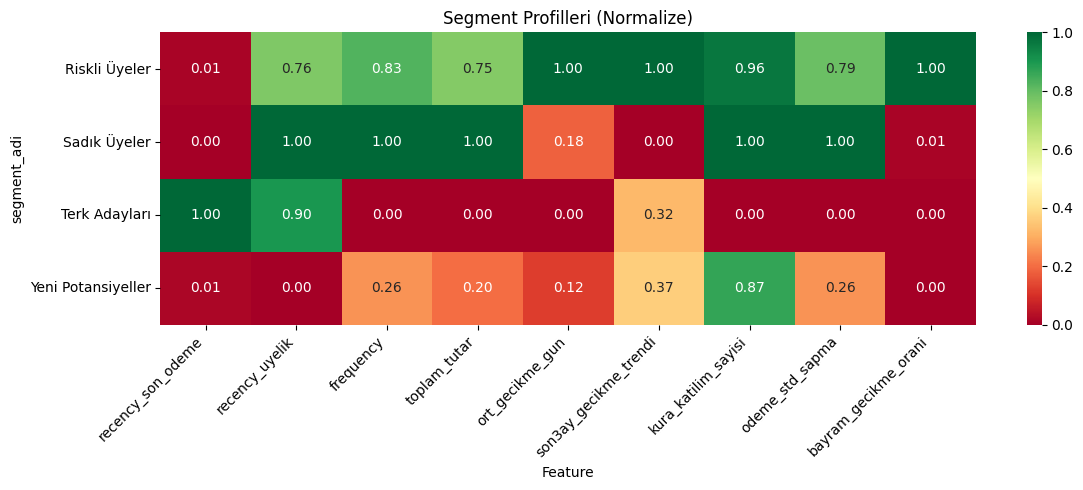

In [13]:
# Normalize edilmiş profil (karşılaştırma için)
profile_norm = df.groupby('segment_adi')[features].mean()
profile_norm = (profile_norm - profile_norm.min()) / (profile_norm.max() - profile_norm.min())

plt.figure(figsize=(12, 5))
sns.heatmap(profile_norm, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            yticklabels=profile_norm.index)
plt.title('Segment Profilleri (Normalize)')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
conn = psycopg2.connect(
    host="localhost",
    port="5432",
    database="tasarruf_finansman", 
    user="postgres",          
    password="2491"      
)

cursor = conn.cursor()

for _, row in df.iterrows():
    cursor.execute("""
        UPDATE dim_member 
        SET member_segment = %s 
        WHERE member_key = %s
    """, (row['segment_adi'], row['member_key']))

conn.commit()
cursor.close()
conn.close()

print("Segmentler yazıldı!")

Segmentler yazıldı!


In [32]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

In [25]:
conn = psycopg2.connect(
    host="localhost",
    port="5432",
    database="tasarruf_finansman",
    user="postgres",
    password="2491"
)

query = """
SELECT 
    member_key,
    MIN(date_key) AS ilk_katilim,
    MAX(CASE WHEN is_winner = true THEN date_key END) AS kazanma_tarihi,
    BOOL_OR(is_winner) AS kura_kazandi
FROM fact_lottery
GROUP BY member_key
"""

df_surv = pd.read_sql(query, conn)
conn.close()

print(df_surv.shape)
df_surv.head()

(9776, 4)


C:\Users\STJ086\AppData\Local\Temp\ipykernel_24336\1854531132.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_surv = pd.read_sql(query, conn)


,member_key,ilk_katilim,kazanma_tarihi,kura_kazandi
0,6114,20240219,NaN,False
1,4790,20230417,NaN,False
2,273,20251117,NaN,False
3,11719,20240926,NaN,False
4,18803,20250426,NaN,False


In [27]:
# int'ten tarihe çevir
df_surv['ilk_katilim'] = pd.to_datetime(
    df_surv['ilk_katilim'].astype(str), 
    format='%Y%m%d'
)

df_surv['kazanma_tarihi'] = pd.to_datetime(
    df_surv['kazanma_tarihi'].astype(str), 
    format='%Y%m%d',
    errors='coerce'  # NaN olanları boş bırak
)

print(df_surv.dtypes)
df_surv.head()

member_key                 int64
ilk_katilim       datetime64[ns]
kazanma_tarihi    datetime64[ns]
kura_kazandi                bool
dtype: object


,member_key,ilk_katilim,kazanma_tarihi,kura_kazandi
0,6114,2024-02-19,NaT,False
1,4790,2023-04-17,NaT,False
2,273,2025-11-17,NaT,False
3,11719,2024-09-26,NaT,False
4,18803,2025-04-26,NaT,False


In [28]:
bugun = pd.Timestamp('2026-06-03')

# Event: kura kazandı mı?
df_surv['event'] = df_surv['kura_kazandi'].astype(int)

# Duration: kaç gün bekledi?
df_surv['bitis'] = df_surv['kazanma_tarihi'].fillna(bugun)
df_surv['duration'] = (df_surv['bitis'] - df_surv['ilk_katilim']).dt.days

print(df_surv[['member_key', 'ilk_katilim', 'kazanma_tarihi', 'duration', 'event']].head(10))
print(f"\nNegatif duration: {(df_surv['duration'] < 0).sum()}")
print(f"Event=1 (kazanan): {df_surv['event'].sum()}")
print(f"Event=0 (censored): {(df_surv['event']==0).sum()}")

   member_key ilk_katilim kazanma_tarihi  duration  event
0        6114  2024-02-19            NaT       835      0
1        4790  2023-04-17            NaT      1143      0
2         273  2025-11-17            NaT       198      0
3       11719  2024-09-26            NaT       615      0
4       18803  2025-04-26            NaT       403      0
5       12502  2022-12-23            NaT      1258      0
6        5761  2023-11-13            NaT       933      0
7        5468  2024-05-25            NaT       739      0
8       13093  2024-10-20            NaT       591      0
9        7662  2023-08-26            NaT      1012      0

Negatif duration: 1641
Event=1 (kazanan): 2590
Event=0 (censored): 7186


In [29]:
df_surv = df_surv[df_surv['duration'] > 0].copy()

print(f"Kalan üye sayısı: {len(df_surv)}")
print(f"Event=1 (kazanan): {df_surv['event'].sum()}")
print(f"Event=0 (censored): {(df_surv['event']==0).sum()}")
print(f"\nDuration özeti:")
print(df_surv['duration'].describe())

Kalan üye sayısı: 8129
Event=1 (kazanan): 1928
Event=0 (censored): 6201

Duration özeti:
count    8129.000000
mean      659.628245
std       388.768941
min         1.000000
25%       329.000000
50%       645.000000
75%       973.000000
max      1524.000000
Name: duration, dtype: float64


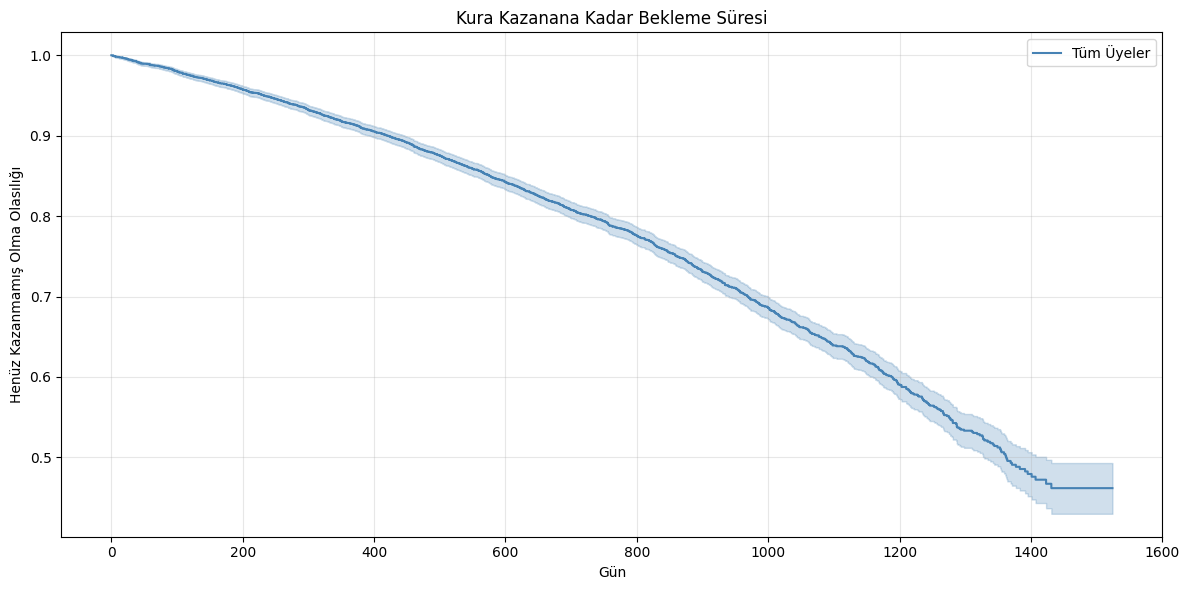

Medyan bekleme süresi: 1362 gün


In [30]:
kmf = KaplanMeierFitter()

kmf.fit(
    durations=df_surv['duration'],
    event_observed=df_surv['event'],
    label='Tüm Üyeler'
)

plt.figure(figsize=(12, 6))
kmf.plot_survival_function(ci_show=True, color='steelblue')

plt.title('Kura Kazanana Kadar Bekleme Süresi')
plt.xlabel('Gün')
plt.ylabel('Henüz Kazanmamış Olma Olasılığı')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Medyan bekleme süresi: {kmf.median_survival_time_:.0f} gün")

In [31]:
for t in [180, 365, 730, 1095, 1362]:
    kazanmamis = kmf.survival_function_at_times(t).values[0]
    kazanmis = 1 - kazanmamis
    print(f"{t:5} gün (~{t//365} yıl {(t%365)//30} ay): "
          f"Kazanma olasılığı %{kazanmis*100:.1f}")

  180 gün (~0 yıl 6 ay): Kazanma olasılığı %3.7
  365 gün (~1 yıl 0 ay): Kazanma olasılığı %8.5
  730 gün (~2 yıl 0 ay): Kazanma olasılığı %20.1
 1095 gün (~3 yıl 0 ay): Kazanma olasılığı %35.8
 1362 gün (~3 yıl 8 ay): Kazanma olasılığı %50.0
